# Analysis and Visualization

### 1. Setup, Data Consolidation, and Results Generation

In [1]:
import sys
import os
# Add the project root directory to the system path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from transformers import DistilBertTokenizer
from src import config
from src.dataset import create_data_loader
from src.model import SentimentClassifier
from src.uncertainty.sngp_model import SNGPClassifier
from src.uncertainty.mc_dropout import get_mc_dropout_predictions
from src.uncertainty.conformal_prediction import conformal_predict, evaluate_conformal

# --- 1. Load all models and resources ---
print("Loading all resources...")
device = torch.device(config.DEVICE)

# a. Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(config.MODEL_NAME)

# b. Load baseline model
baseline_model = SentimentClassifier(n_classes=config.N_CLASSES)
baseline_model_path = os.path.join(
    config.SAVED_MODELS_PATH, config.SAVED_MODELS_NAME)
baseline_model.load_state_dict(torch.load(
    baseline_model_path, map_location=device))
baseline_model = baseline_model.to(device)
baseline_model.eval()

# c. Loading the SNGP model
sngp_model = SNGPClassifier(n_classes=config.N_CLASSES)
sngp_model_path = os.path.join(
    config.SAVED_MODELS_PATH, config.SAVED_SNGP_MODELS_NAME)
sngp_model.load_state_dict(torch.load(sngp_model_path, map_location=device))
sngp_model = sngp_model.to(device)
sngp_model.eval()

# d. Load UQ parameters
OPTIMAL_TEMPERATURE = config.get_uq_param('temperature')
Q_HAT = config.get_uq_param('conformal_q_hat')
ALPHA = config.get_uq_param('conformal_alpha')
MCD_SAMPLING_TIMES = config.get_uq_param('mc_sampling_times')

# e. Data loader for loading test and validation sets
test_loader = create_data_loader(os.path.join(
    config.PROCESSED_DATA_PATH, config.TEST_FILE_NAME), tokenizer, config.MAX_LEN, config.BATCH_SIZE)
val_loader = create_data_loader(os.path.join(
    config.PROCESSED_DATA_PATH, config.VALIDATION_FILE_NAME), tokenizer, config.MAX_LEN, config.BATCH_SIZE)

print("All resources loaded!")


# --- 2. Generate the results of all methods uniformly on the test set ---
print("\n" + "="*20 + " Generating prediction results for all methods " + "="*20)

# a. Obtain the raw outputs of the baseline model and SNGP model on the test set


@torch.no_grad()
def get_model_outputs(model, data_loader):
    model.eval()
    all_logits, all_probs, all_labels = [], [], []
    for d in tqdm(data_loader, desc=f"Getting outputs for {model.__class__.__name__}"):
        input_ids, attention_mask, labels = d["input_ids"].to(
            device), d["attention_mask"].to(device), d["labels"].to(device)
        logits = model(input_ids, attention_mask)
        all_logits.append(logits)
        all_probs.append(F.softmax(logits, dim=1))
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_probs), torch.cat(all_labels)


baseline_logits, baseline_probs, test_labels_t = get_model_outputs(
    baseline_model, test_loader)
sngp_logits, sngp_probs, _ = get_model_outputs(sngp_model, test_loader)

# b. Calculate the result of Temperature Scaling
ts_probs = F.softmax(baseline_logits / OPTIMAL_TEMPERATURE, dim=1)

# c. Calculate the result of MC Dropout
mcd_results = get_mc_dropout_predictions(
    baseline_model, test_loader, n_samples=MCD_SAMPLING_TIMES, device=device)
mcd_probs = torch.from_numpy(mcd_results['mean_probs']).to(device)

# d. Calculate the results of Conformal Prediction
calib_logits, calib_probs, calib_labels_t = get_model_outputs(
    baseline_model, val_loader)
cp_sets = conformal_predict(calib_probs.cpu().numpy(
), calib_labels_t.cpu().numpy(), baseline_probs.cpu().numpy(), ALPHA)

print("\n" + "="*20 + " All results are ready " + "="*20)

# --- 3. Organize all results for future reference ---
# Real labels (converted to numpy)
y_true = test_labels_t.cpu().numpy()

# Probability outputs of various methods (converted to numpy)
results_probs = {
    "Baseline": baseline_probs.cpu().numpy(),
    "Temp. Scaling": ts_probs.cpu().numpy(),
    "MC Dropout": mcd_probs.cpu().numpy(),
    "SNGP": sngp_probs.cpu().numpy()
}

# Prediction labels using various methods
results_preds = {name: np.argmax(probs, axis=1)
                 for name, probs in results_probs.items()}

# Exclusive results of conformal prediction
cp_coverage, cp_avg_set_size = evaluate_conformal(y_true, cp_sets)

print("Visual analysis variables are ready: 'y_true', 'results_probs', 'results_preds', 'cp_sets'")
print(
    f"Conformal Prediction result: Coverage={cp_coverage:.4f}, Avg Set Size={cp_avg_set_size:.4f}")

Loading all resources...
All resources loaded!

==================== Generating prediction results for all methods ====================


Generating Prediction Sets: 100%|██████████| 4991/4991 [00:00<00:00, 612313.42it/s]


==================== All results are ready ====================
Visual analysis variables are ready: 'y_true', 'results_probs', 'results_preds', 'cp_sets'
Conformal Prediction result: Coverage=0.9527, Avg Set Size=1.4091


---
### 2.Prediction Performance Comparison - F1 Score Comparison Bar Chart

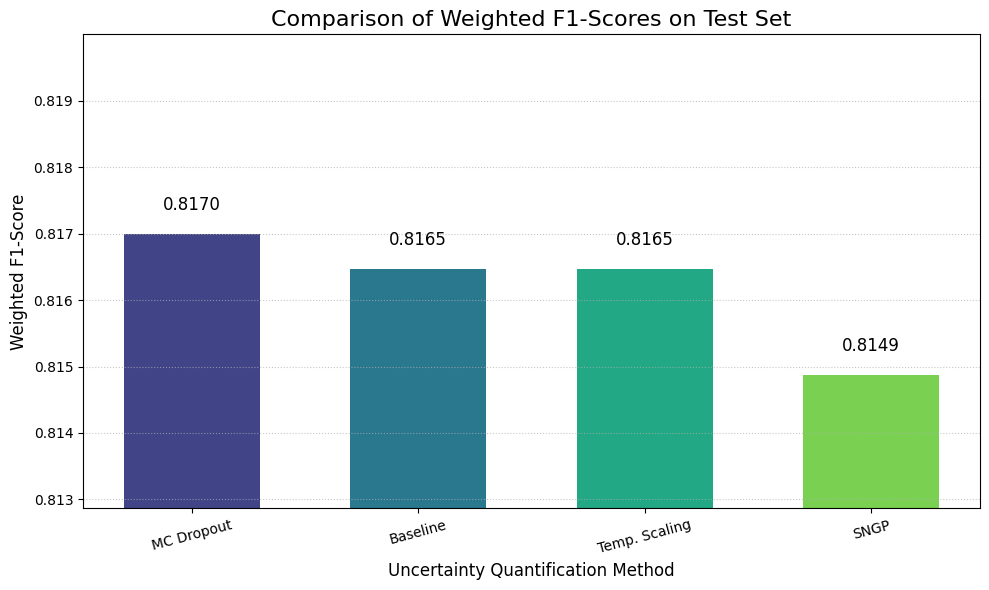

In [3]:
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Calculate F1 score ---
f1_scores = {}
for method_name, y_pred in results_preds.items():
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_scores[method_name] = f1

f1_scores_for_plot = f1_scores.copy()
# The evaluation of Normal Prediction does not rely on F1 score, please remove it from this graph
df_f1 = pd.DataFrame(list(f1_scores_for_plot.items()), columns=[
                     'Method', 'F1-Score']).sort_values('F1-Score', ascending=False)

# --- 2. Start drawing ---
plt.figure(figsize=(10, 6))

colors = sns.color_palette('viridis', n_colors=len(df_f1))
bars = plt.bar(
    df_f1['Method'],
    df_f1['F1-Score'],
    color=colors,
    width=0.6
)

plt.title('Comparison of Weighted F1-Scores on Test Set', fontsize=16)
plt.xlabel('Uncertainty Quantification Method', fontsize=12)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.xticks(rotation=15)

min_f1 = df_f1['F1-Score'].min()
max_f1 = df_f1['F1-Score'].max()

# Dynamically adjust the Y-axis range to make the differences more pronounced
plt.ylim(min_f1 - 0.002, max_f1 + 0.003)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0003, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='dotted', alpha=0.7)
plt.tight_layout()
plt.show()

---
### 3.Calibration Performance Comparison - Comprehensive Reliability Diagram

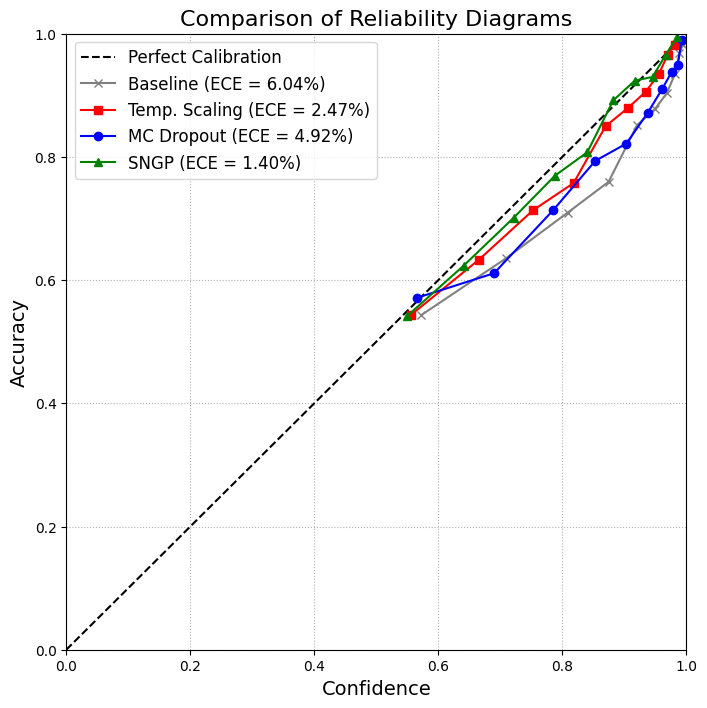

In [4]:
import matplotlib.pyplot as plt
from src.uncertainty.temperature_scaling import calculate_ece_adaptive, get_adaptive_bins

plt.figure(figsize=(8, 8))
# Draw the perfect diagonal line
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")

# Define colors and markings
colors = {
    "Baseline": "grey",
    "Temp. Scaling": "red",
    "MC Dropout": "blue",
    "SNGP": "green"
}
markers = {
    "Baseline": "x",
    "Temp. Scaling": "s",
    "MC Dropout": "o",
    "SNGP": "^"
}

n_bins = 10
# Traverse each method, calculate and plot its calibration curve
for method_name, probs in results_probs.items():
    # Calculate ECE score
    ece = calculate_ece_adaptive(probs, y_true, n_bins)
    avg_conf, accuracy_in_bin = get_adaptive_bins(probs, y_true, n_bins)

    plt.plot(
        avg_conf,
        accuracy_in_bin,
        marker=markers[method_name],
        linestyle='-',
        color=colors[method_name],
        label=f"{method_name} (ECE = {ece:.2f}%)"
    )

plt.xlabel("Confidence", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Comparison of Reliability Diagrams", fontsize=16)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='dotted')
plt.legend(loc="upper left", fontsize=12)
plt.show()

#### 3.1 Special Case Analysis - Lack of Confidence in the SNGP Curve

In [5]:
import pandas as pd
import numpy as np
import os
from src import config

if 'test_df' not in locals():
    test_df = pd.read_csv(os.path.join(
        config.PROCESSED_DATA_PATH, config.TEST_FILE_NAME))

# --- 1. Extract the results of the SNGP model ---
sngp_probs = results_probs['SNGP']
sngp_confidences = np.max(sngp_probs, axis=1)
sngp_predictions = np.argmax(sngp_probs, axis=1)

# --- 2. Define filtering criteria ---
correct_mask = (sngp_predictions == y_true)
# Filter out the data with SNGP curve higher than the perfect curve
CONFIDENCE_THRESHOLD = 0.9
underconfident_mask = sngp_confidences < CONFIDENCE_THRESHOLD
final_mask = correct_mask & underconfident_mask
filtered_indices = np.where(final_mask)[0]

print(f"Found {len(filtered_indices)} unconfident samples predicted correctly by the SNGP model but with a confidence level less than {CONFIDENCE_THRESHOLD} ")

# --- 3. Extract and save these samples ---
if len(filtered_indices) > 0:
    underconfident_samples_df = test_df.iloc[filtered_indices].copy()

    underconfident_samples_df['true_label'] = y_true[filtered_indices]
    underconfident_samples_df['predicted_label'] = sngp_predictions[filtered_indices]
    underconfident_samples_df['confidence'] = sngp_confidences[filtered_indices]
    underconfident_samples_df['is_correct'] = 1

    class_map = {i: name for i, name in enumerate(config.CLASS_NAMES)}
    underconfident_samples_df['true_label_name'] = underconfident_samples_df['true_label'].map(
        class_map)
    underconfident_samples_df['predicted_label_name'] = underconfident_samples_df['predicted_label'].map(
        class_map)

    # --- 4. Save in CSV file ---
    OUTPUT_DIR = '../report/'
    OUTPUT_FILENAME = '3_1_sngp_underconfident_correct_samples.csv'
    OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    underconfident_samples_df.to_csv(
        OUTPUT_PATH, index=False, encoding='utf-8-sig')

    print(f"\nThese samples have been saved to: {OUTPUT_PATH}")
else:
    print("\nNo samples that meet the criteria were found under the current threshold.")

Found 2154 unconfident samples predicted correctly by the SNGP model but with a confidence level less than 0.9 

These samples have been saved to: ../report/3_1_sngp_underconfident_correct_samples.csv


In [6]:
# 1. Prepare analysis data for the SNGP method
sngp_analysis_df = test_df.copy()
sngp_analysis_df['predicted_label'] = results_preds['SNGP']
sngp_analysis_df['is_correct'] = (
    sngp_analysis_df['predicted_label'] == y_true)

# 2. Calculate the entropy of SNGP as the uncertainty score
sngp_probs = results_probs['SNGP']
sngp_entropy = -np.sum(sngp_probs * np.log(sngp_probs + 1e-10), axis=1)
sngp_analysis_df['uncertainty'] = sngp_entropy

# 3. Screen out correctly predicted samples for analysis
sngp_correct_df = sngp_analysis_df[sngp_analysis_df['is_correct'] == True].copy()

# 4. Call analysis method
config.analyze_features_by_group(
    sngp_correct_df, uncertainty_col='uncertainty', group_name="SNGP")


==================== SNGP Comparative analysis of features ====================

--- Analysis Group: Certain Positive (SNGP) (contains 1078 samples in total) ---
  - Average number of [Positive] words: 0.35
  - Average number of [Negative] words: 0.00
  - Proportion of transitional words included: 2.69%
  - Average text length: 10.52 words

--- Analysis Group: Certain Negative (SNGP) (contains 956 samples in total) ---
  - Average number of [Positive] words: 0.07
  - Average number of [Negative] words: 0.08
  - Proportion of transitional words included: 17.68%
  - Average text length: 11.55 words

--- Analysis Group: Uncertain Positive (SNGP) (contains 954 samples in total) ---
  - Average number of [Positive] words: 0.15
  - Average number of [Negative] words: 0.02
  - Proportion of transitional words included: 14.15%
  - Average text length: 12.86 words

--- Analysis Group: Uncertain Negative (SNGP) (contains 1079 samples in total) ---
  - Average number of [Positive] words: 0.08
  

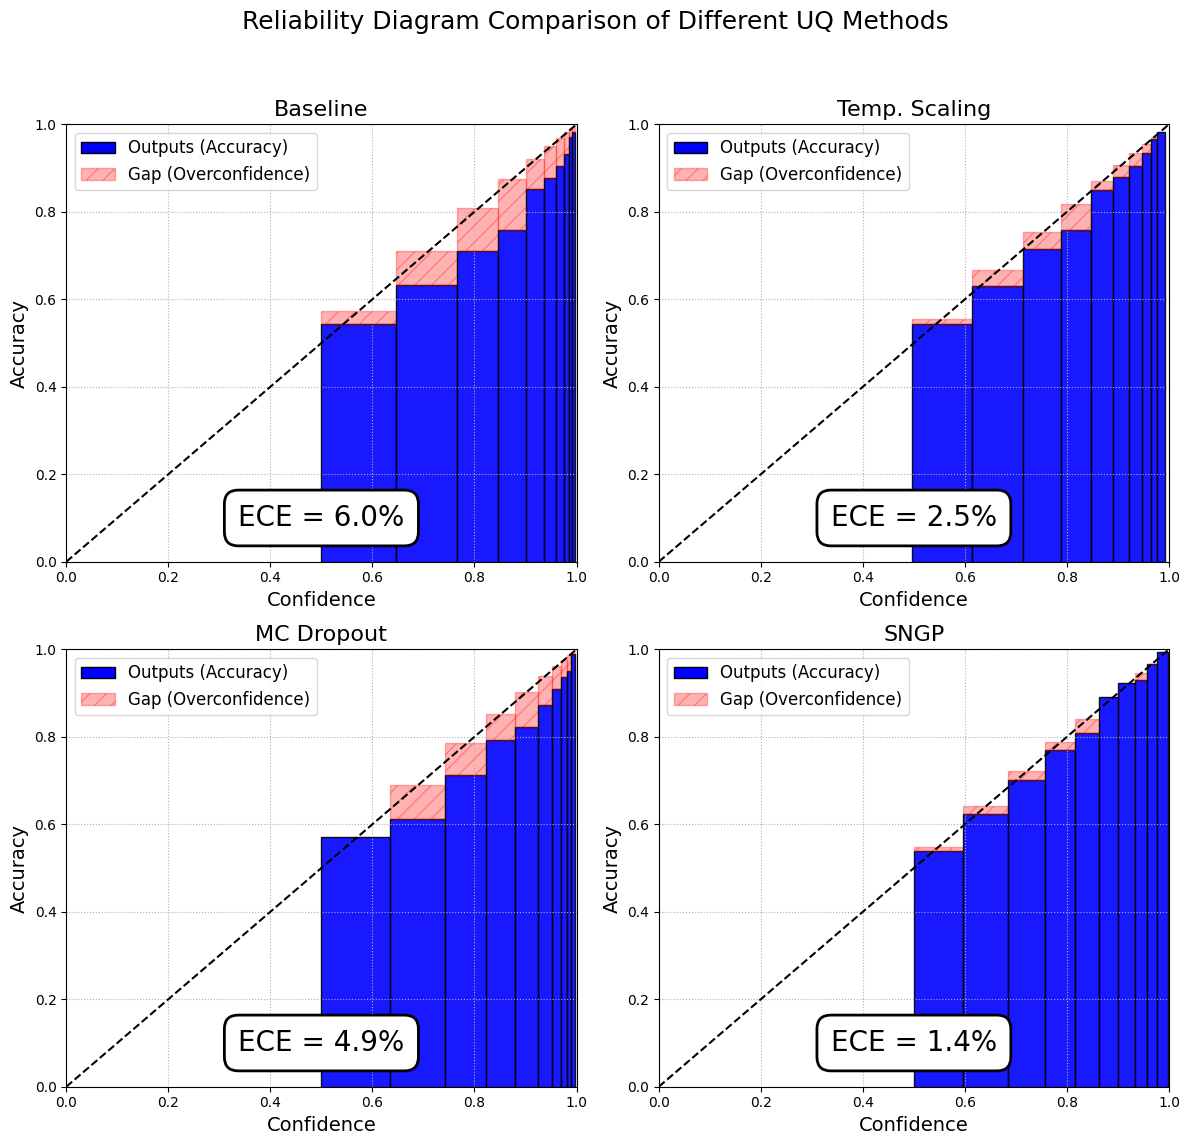

In [26]:
import matplotlib.pyplot as plt
from src.uncertainty.temperature_scaling import plot_reliability_diagram_final

# --- 1. Create a 1x4 subgraph layout and loop through the drawing process ---
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Loop through each method and plot on the corresponding subgraph
for i, method_name in enumerate(methods_to_plot):
    probs = results_probs[method_name]
    ax = axes[i // 2, i % 2]
    plot_reliability_diagram_final(
        ax,  # Pass the correct subplot axis
        probs,
        y_true,
        method_name
    )

fig.suptitle("Reliability Diagram Comparison of Different UQ Methods", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

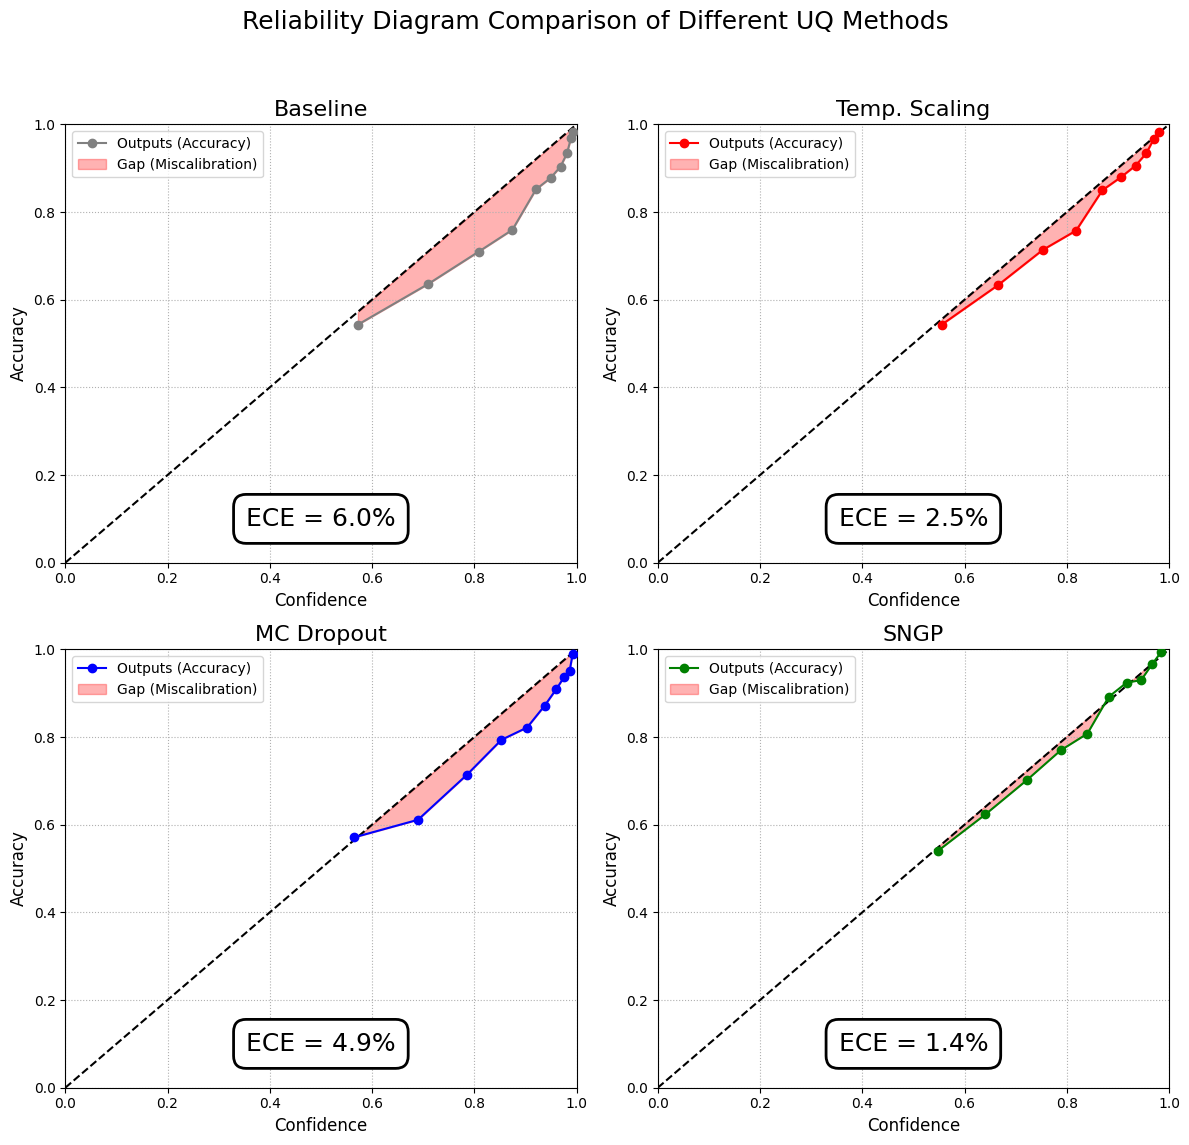

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty.temperature_scaling import plot_reliability_diagram_line_style

# --- 1. Create a 1x4 subgraph layout and loop through the drawing process ---
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
colors = ["grey", "red", "blue", "green"]
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for i, method_name in enumerate(methods_to_plot):
    probs = results_probs[method_name]
    ax = axes[i // 2, i % 2]
    
    plot_reliability_diagram_line_style(
        ax,
        probs,
        y_true,
        method_name,
        color=colors[i]
    )

fig.suptitle("Reliability Diagram Comparison of Different UQ Methods", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
### 4. Uncertainty Scores Quality Comparison - Comprehensive Accuracy Coverage Curve

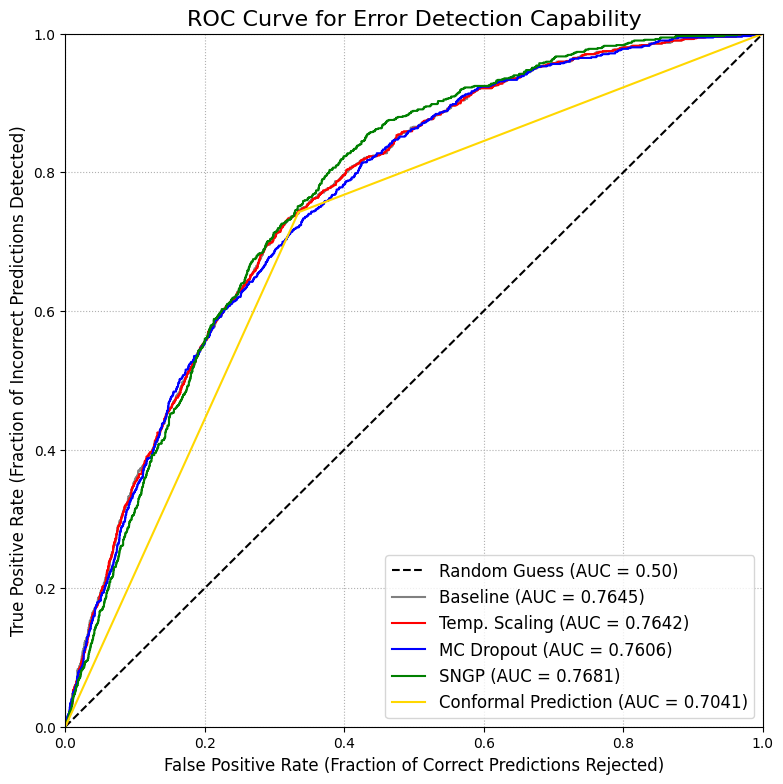

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare the data required for drawing ---
y_true_for_roc = (results_preds['Baseline'] != y_true).astype(int)
uncertainty_scores = {
    "Baseline": -np.sum(results_probs['Baseline'] * np.log(results_probs['Baseline'] + 1e-10), axis=1),
    "Temp. Scaling": -np.sum(results_probs['Temp. Scaling'] * np.log(results_probs['Temp. Scaling'] + 1e-10), axis=1),
    "MC Dropout": -np.sum(results_probs['MC Dropout'] * np.log(results_probs['MC Dropout'] + 1e-10), axis=1),
    "SNGP": -np.sum(results_probs['SNGP'] * np.log(results_probs['SNGP'] + 1e-10), axis=1),
    "Conformal Prediction": np.array([len(s) for s in cp_sets])
}

# --- 2. Start drawing ---
plt.figure(figsize=(9, 9))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

colors = {
    "Baseline": "grey",
    "Temp. Scaling": "red",
    "MC Dropout": "blue",
    "SNGP": "green",
    "Conformal Prediction": "gold"
}

linestyles = {
    "Baseline": "-",
    "Temp. Scaling": "-",
    "MC Dropout": "-",
    "SNGP": "-",
    "Conformal Prediction": "-"
}

# Loop through each method and draw using the specified color and line type
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP", "Conformal Prediction"]
for method_name in methods_to_plot:
    scores = uncertainty_scores[method_name]
    fpr, tpr, _ = roc_curve(y_true_for_roc, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, 
        tpr, 
        color=colors[method_name],
        linestyle=linestyles[method_name],
        lw=1.5,
        label=f'{method_name} (AUC = {roc_auc:.4f})'
    )

plt.xlabel('False Positive Rate (Fraction of Correct Predictions Rejected)', fontsize=12)
plt.ylabel('True Positive Rate (Fraction of Incorrect Predictions Detected)', fontsize=12)
plt.title('ROC Curve for Error Detection Capability', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='dotted')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.show()

---
### 5.Comparison of Uncertainty Distribution in Error Detection - Uncertainty Distribution Chart

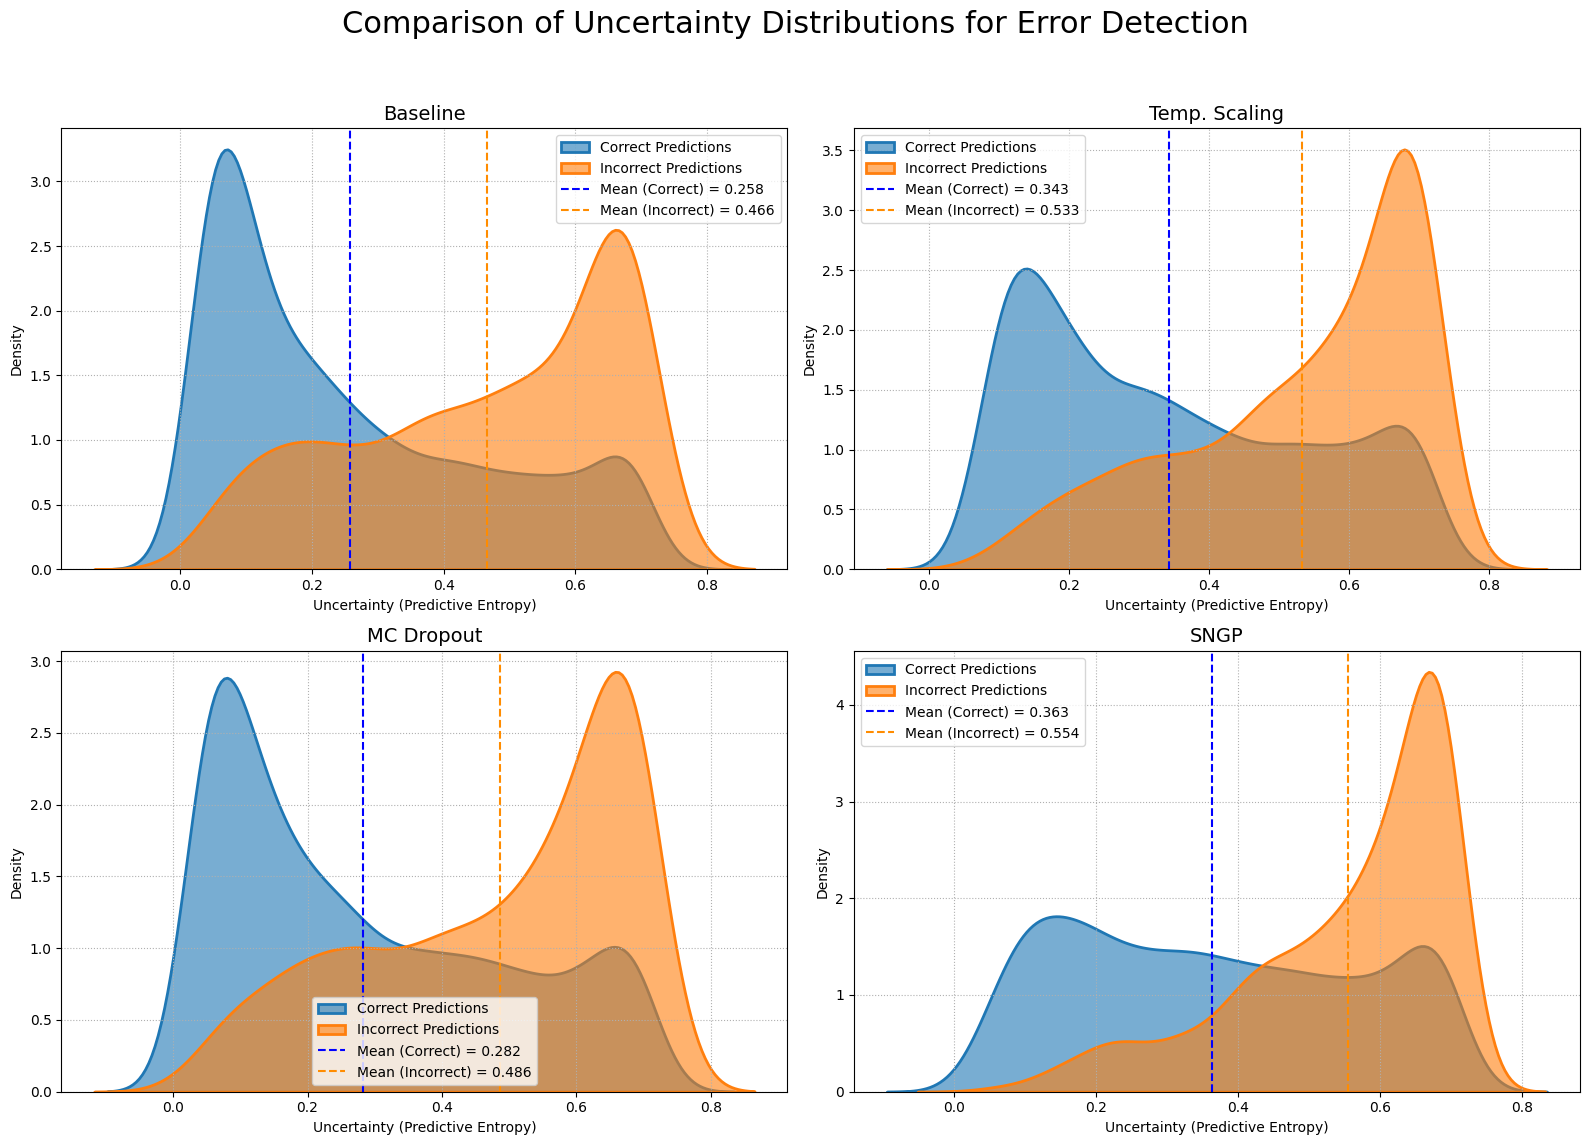

In [10]:
import matplotlib.pyplot as plt
from src.uncertainty.mc_dropout import plot_uncertainty_distribution

# 1. Create a 2x2 subgraph layout and loop through the drawing process
methods_to_plot = ["Baseline", "Temp. Scaling", "MC Dropout", "SNGP"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
correct_mask = (y_true_for_roc == 0)

# 2.Loop through each method and plot on the corresponding subgraph
for i, method_name in enumerate(methods_to_plot):
    ax = axes.flatten()[i]
    scores = uncertainty_scores[method_name]
    plot_uncertainty_distribution(ax, scores, correct_mask, method_name)

fig.suptitle("Comparison of Uncertainty Distributions for Error Detection", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 5.1 Analysis of Three Special Situations

In [11]:
import numpy as np
import os

OUTPUT_DIR = '../report/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------------------------------------------------------------------------------
# Scenario 1: Why is the blue peak of SNGP significantly lower than other methods?
# Screening criteria: The prediction is correct and the uncertainty is extremely low (entropy<0.1)

# a. Condition 1: Both the baseline model and SNGP predict correctly
correct_mask_baseline = (results_preds['Baseline'] == y_true)
correct_mask_sngp = (results_preds['SNGP'] == y_true)
both_correct_mask = correct_mask_baseline & correct_mask_sngp

# b. Condition 2: The baseline model is extremely confident (with very low entropy)
baseline_confident_mask = uncertainty_scores['Baseline'] < 0.1

# c. Condition 3: The SNGP model is relatively more cautious (entropy is not as low)
sngp_tempered_mask = uncertainty_scores['SNGP'] > 0.1

# d. Combine all conditions to find the target sample
final_mask_s1 = both_correct_mask & baseline_confident_mask & sngp_tempered_mask
sngp_scenario1_indices = np.where(final_mask_s1)[0]

# e. Extract data and add new columns required for comparison
sngp_scenario1_df = test_df.iloc[sngp_scenario1_indices].copy()
sngp_scenario1_df['uncertainty_baseline'] = uncertainty_scores['Baseline'][sngp_scenario1_indices]
sngp_scenario1_df['uncertainty_sngp'] = uncertainty_scores['SNGP'][sngp_scenario1_indices]

# f. Save data into file
sngp_scenario1_df.to_csv(os.path.join(
    OUTPUT_DIR, '3_5_scenario1_sngp_calibration_effect.csv'), index=False)
print(
    f"\nScenario 1: Found {len(sngp_scenario1_df)} samples where the baseline model is extremely confident while SNGP is more cautious.")


# --------------------------------------------------------------------------------
# Scenario 2: Why is there no small peak in the orange curve of SNGP between 0.15-0.3?
# Screening criteria: prediction error and uncertainty between 0.15 and 0.3
# --------------------------------------------------------------------------------
incorrect_mask = (y_true_for_roc == 1)
baseline_mid_uncertainty_mask = (uncertainty_scores['Baseline'] > 0.15) & (
    uncertainty_scores['Baseline'] < 0.3)
baseline_scenario2_indices = np.where(
    incorrect_mask & baseline_mid_uncertainty_mask)[0]
baseline_scenario2_df = test_df.iloc[baseline_scenario2_indices].copy()
baseline_scenario2_df['uncertainty_baseline'] = uncertainty_scores['Baseline'][baseline_scenario2_indices]
baseline_scenario2_df.to_csv(os.path.join(
    OUTPUT_DIR, '3_5_scenario2_baseline_confident_errors.csv'), index=False)
print(f"Scenario 2: Found {len(baseline_scenario2_df)} baseline model 'confident errors' samples (entropy between 0.15-0.3).")


# --------------------------------------------------------------------------------
# Scenario 3: Why does the blue curve have a sudden peak between 0.6-0.7?
# Screening criteria: The prediction is correct and the uncertainty is between 0.6 and 0.7
# --------------------------------------------------------------------------------
correct_mask_sngp_s3 = (results_preds['SNGP'] == y_true)
high_uncertainty_mask_correct = (uncertainty_scores['SNGP'] > 0.6) & (
    uncertainty_scores['SNGP'] < 0.7)
sngp_scenario3_indices = np.where(
    correct_mask_sngp_s3 & high_uncertainty_mask_correct)[0]
sngp_scenario3_df = test_df.iloc[sngp_scenario3_indices].copy()
sngp_scenario3_df['uncertainty_sngp'] = uncertainty_scores['SNGP'][sngp_scenario3_indices]
sngp_scenario3_df.to_csv(os.path.join(
    OUTPUT_DIR, '3_5_scenario3_sngp_uncertain_correct.csv'), index=False)
print(f"Scenario 3: Found {len(sngp_scenario3_df)} SNPP 'uncertain correct' samples (entropy between 0.6-0.7).")

print(f"\nAll filtering results have been saved to '{OUTPUT_DIR}'")

# Preview some samples
print("\n--- Scenario 1 Preview: Baseline Model Overconfident in Correct Sentences ---")
display(sngp_scenario1_df.head())
print("\n--- Scenario 2 Preview: Sentences in which the baseline model confidently makes mistakes ---")
display(baseline_scenario2_df.head())
print("\n--- Scenario 3 Preview: The sentence in which the SNGP model hesitates but answers correctly ---")
display(sngp_scenario3_df.head())


Scenario 1: Found 923 samples where the baseline model is extremely confident while SNGP is more cautious.
Scenario 2: Found 135 baseline model 'confident errors' samples (entropy between 0.15-0.3).
Scenario 3: Found 722 SNPP 'uncertain correct' samples (entropy between 0.6-0.7).

All filtering results have been saved to '../report/'

--- Scenario 1 Preview: Baseline Model Overconfident in Correct Sentences ---


,text,date,user,sentiment,query,uncertainty_baseline,uncertainty_sngp
4,wheres the sunshine gone,Sun May 17 00:45:18 PDT 2009,vathenaEU,0,NO_QUERY,0.036931,0.101513
13,yay thanks for sharing are you feeling better ...,Sun May 31 01:02:14 PDT 2009,subslavesteve,2,NO_QUERY,0.056085,0.112006
20,mmmm not looking forward to tomorrow and not e...,Sun Jun 07 12:58:26 PDT 2009,lizclark88,0,NO_QUERY,0.091247,0.137342
27,like your blog post on amsterdam too my place ...,Sun May 17 10:14:51 PDT 2009,tuminds,2,NO_QUERY,0.079163,0.320550
33,well today was amazing i adore you babe lt,Sat May 30 21:09:21 PDT 2009,RancesorusRex,2,NO_QUERY,0.087177,0.205993



--- Scenario 2 Preview: Sentences in which the baseline model confidently makes mistakes ---


,text,date,user,sentiment,query,uncertainty_baseline
9,sooo its a bootiful sunday my first proper sit...,Sun Jun 07 02:23:03 PDT 2009,FaHizzle,0,NO_QUERY,0.256198
100,ive a sneaky suspiscion she too k it with er,Sat May 30 16:11:03 PDT 2009,justhalo,0,NO_QUERY,0.220064
181,how did your wife take it,Tue Jun 02 21:00:42 PDT 2009,SweetDahlia,0,NO_QUERY,0.210360
200,good night twitter addicts have a very nice we...,Mon Jun 01 01:24:29 PDT 2009,joanneistheshit,2,NO_QUERY,0.159338
204,yes not my favourite of places but need to sen...,Sat May 30 01:25:52 PDT 2009,felicityfuller,0,NO_QUERY,0.208340



--- Scenario 3 Preview: The sentence in which the SNGP model hesitates but answers correctly ---


,text,date,user,sentiment,query,uncertainty_sngp
11,coachella i want to go sing the cure for me,Sat Apr 18 22:37:08 PDT 2009,taniia_r,0,NO_QUERY,0.649878
19,im in my room eating some of my moms amazing n...,Sun May 17 11:58:04 PDT 2009,Singingirlx10,2,NO_QUERY,0.637400
28,y i gotta b talkin bout clubbin y cant i b tal...,Fri May 29 10:57:39 PDT 2009,MSEDITH88,0,NO_QUERY,0.672038
30,hiya yes i have rebooted and it still isnt rig...,Sun May 17 05:15:01 PDT 2009,felicityfuller,0,NO_QUERY,0.658918
69,going to take a shower and then homework,Sun May 03 08:45:58 PDT 2009,lovefrustration,0,NO_QUERY,0.607183


In [12]:
import pandas as pd
import os
from src import config

# --- Start analyzing scenario one ---
file_path = os.path.join('../report/', '3_5_scenario1_sngp_calibration_effect.csv')

if os.path.exists(file_path):
    df_s1 = pd.read_csv(file_path)
    
    # Calculate features
    pos_words = df_s1['text'].apply(lambda x: config._count_sentiment_words(x, config.POSITIVE_WORDS)).mean()
    neg_words = df_s1['text'].apply(lambda x: config._count_sentiment_words(x, config.NEGATIVE_WORDS)).mean()
    contrast_ratio = df_s1['text'].apply(config._contains_transitional_words).mean()
    text_len = df_s1['text'].apply(config._get_text_length).mean()

    print("="*30 + " Scenario 1: Quantitative Analysis Report " + "="*30)
    print("Analysis object: Samples with extreme confidence in baseline models and more cautious SNGP")
    print(f"(Total {len(df_s1)} samples)")
    print("-" * 84)
    print(f"  - Average number of positive words: {pos_words:.2f}")
    print(f"  - Average number of negative words: {neg_words:.2f}")
    print(f"  - Proportion of transitional words: {contrast_ratio:.2%}")
    print(f"  - Average text length: {text_len:.2f} words")
    print("="*84)
else:
    print("CSV file for scene one not found, skip analysis.")

============================== Scenario 1: Quantitative Analysis Report ==============================
Analysis object: Samples with extreme confidence in baseline models and more cautious SNGP
(Total 923 samples)
------------------------------------------------------------------------------------
  - Average number of positive words: 0.24
  - Average number of negative words: 0.02
  - Proportion of transitional words: 8.67%
  - Average text length: 11.13 words


In [13]:
# --- Start analyzing scenario two ---
file_path_s2 = os.path.join(
    '../report/', '3_5_scenario2_baseline_confident_errors.csv')

if os.path.exists(file_path_s2):
    # a. Loading experimental group (confident error)
    df_s2_errors = pd.read_csv(file_path_s2)

    # b. Create a control group (confident correct)
    correct_mask = (y_true_for_roc == 0)
    confident_mask = uncertainty_scores['Baseline'] < 0.3
    baseline_certain_correct_indices = np.where(
        correct_mask & confident_mask)[0]
    df_s2_correct = test_df.iloc[baseline_certain_correct_indices].copy()

    # c. Calculate the features of two groups separately
    groups_s2 = {"Baseline 'Error of Confidence' (Experimental Group)": df_s2_errors,
                 "Baseline 'Confident Correctness' (Control Group)": df_s2_correct}

    print("\n" + "="*30 + " Scenario 2: Quantitative Analysis Report " + "="*30)
    for name, df in groups_s2.items():
        pos_words = df['text'].apply(
            lambda x: config._count_sentiment_words(x, config.POSITIVE_WORDS)).mean()
        neg_words = df['text'].apply(
            lambda x: config._count_sentiment_words(x, config.NEGATIVE_WORDS)).mean()
        contrast_ratio = df['text'].apply(
            config._contains_transitional_words).mean()
        text_len = df['text'].apply(config._get_text_length).mean()

        print(f"\n-- Analysis Group: {name} (Total {len(df)} samples) ---")
        print(f"  - Average number of positive words: {pos_words:.2f}")
        print(f"  - Average number of negative words: {neg_words:.2f}")
        print(f"  - Proportion of transitional words: {contrast_ratio:.2%}")
        print(f"  - Average text length: {text_len:.2f} words")
    print("="*84)
else:
    print("CSV file for scenario 2 not found, skip analysis.")


============================== Scenario 2: Quantitative Analysis Report ==============================

-- Analysis Group: Baseline 'Error of Confidence' (Experimental Group) (Total 135 samples) ---
  - Average number of positive words: 0.12
  - Average number of negative words: 0.03
  - Proportion of transitional words: 16.30%
  - Average text length: 12.03 words

-- Analysis Group: Baseline 'Confident Correctness' (Control Group) (Total 2647 samples) ---
  - Average number of positive words: 0.20
  - Average number of negative words: 0.03
  - Proportion of transitional words: 11.11%
  - Average text length: 11.37 words


In [14]:
# --- Start analyzing scenario three ---
file_path_s3 = os.path.join(
    '../report/', '3_5_scenario3_sngp_uncertain_correct.csv')

if os.path.exists(file_path_s3):
    # a. Loading experimental group (unconfident correct)
    df_s3_uncertain = pd.read_csv(file_path_s3)

    # b. Create a control group (confident correct)
    correct_mask_sngp = (results_preds['SNGP'] == y_true)
    confident_mask_sngp = uncertainty_scores['SNGP'] < 0.3
    sngp_certain_correct_indices = np.where(
        correct_mask_sngp & confident_mask_sngp)[0]
    df_s3_certain = test_df.iloc[sngp_certain_correct_indices].copy()

    # c. Calculate the features of two groups separately
    groups_s3 = {"SNPP 'unconfident correctness' (Experimental Group)": df_s3_uncertain,
                 "SNPP 'Confident Correctness' (Control Group)": df_s3_certain}

    print("\n" + "="*30 + " Scenario 3: Quantitative Analysis Report " + "="*30)
    for name, df in groups_s3.items():
        pos_words = df['text'].apply(
            lambda x: config._count_sentiment_words(x, config.POSITIVE_WORDS)).mean()
        neg_words = df['text'].apply(
            lambda x: config._count_sentiment_words(x, config.NEGATIVE_WORDS)).mean()
        contrast_ratio = df['text'].apply(
            config._contains_transitional_words).mean()
        text_len = df['text'].apply(config._get_text_length).mean()

        print(f"\n--- Analysis Group: {name} (Total {len(df)} samples) ---")
        print(f"  - Average number of positive words: {pos_words:.2f}")
        print(f"  - Average number of negative words: {neg_words:.2f}")
        print(f"  - Proportion of transitional words: {contrast_ratio:.2%}")
        print(f"  - Average text length: {text_len:.2f} words")
    print("="*84)
else:
    print("CSV file for scenario three not found, skip analysis.")


============================== Scenario 3: Quantitative Analysis Report ==============================

--- Analysis Group: SNPP 'unconfident correctness' (Experimental Group) (Total 722 samples) ---
  - Average number of positive words: 0.11
  - Average number of negative words: 0.02
  - Proportion of transitional words: 21.61%
  - Average text length: 13.80 words

--- Analysis Group: SNPP 'Confident Correctness' (Control Group) (Total 1749 samples) ---
  - Average number of positive words: 0.23
  - Average number of negative words: 0.04
  - Proportion of transitional words: 9.32%
  - Average text length: 10.77 words


---
### 6.Performance and Time Comparison Analysis

In [15]:
import pandas as pd
import numpy as np
import time
import os
from src import config
from src.uncertainty.conformal_prediction import find_conformal_threshold

# --- 1. Prepare Data ---
# a. Performance indicators (from ROC curve analysis)
auc_scores = {
    "Baseline": 0.7645,
    "Temp. Scaling": 0.7642,
    "MC Dropout": 0.7625,
    "SNGP": 0.7681,
    "Conformal Prediction": 0.7041
}

# b. Single inference cost (from previous timing)
inference_times = {
    'Baseline': 13.97,
    'Temp. Scaling': 13.97,
    'Conformal Prediction': 13.97,
    'MC Dropout': 246.16,
    'SNGP': 10.36
}


# --- 2. Preliminary preparation expenses ---

# a. Training time (approximately 7 minutes per epoch according to the training log)
baseline_training_time_mins = 7 * 5
sngp_training_time_mins = 7 * 5

# b. Calibration time
ts_calibration_time_secs = 0.1
val_loader_for_timing = create_data_loader(os.path.join(
    config.PROCESSED_DATA_PATH, config.VALIDATION_FILE_NAME), tokenizer, config.MAX_LEN, config.BATCH_SIZE)
start_time = time.time()
_ = find_conformal_threshold(
    baseline_model, val_loader_for_timing, device, alpha=0.05)
cp_calibration_time_secs = time.time() - start_time


upfront_costs = {
    "Baseline": f"{baseline_training_time_mins:.1f} min (Train)",
    "Temp. Scaling": f"~{baseline_training_time_mins:.1f} min (Train + {ts_calibration_time_secs:.1f}s Validation)",
    "MC Dropout": f"{baseline_training_time_mins:.1f} min (Train)",
    "Conformal Prediction": f"~{baseline_training_time_mins:.1f} min (Train + {cp_calibration_time_secs:.1f}s Validation)",
    "SNGP": f"{sngp_training_time_mins:.1f} min (Train)"
}


# --- 3. Create and display the final summary table ---
summary_data = []
for method in auc_scores.keys():
    summary_data.append({
        "Method": method,
        "AUC": auc_scores.get(method),
        "Preliminary Preparation Cost": upfront_costs.get(method),
        "Single Inference Time Cost": inference_times.get(method)
    })

df_summary = pd.DataFrame(summary_data).set_index("Method")

print("="*30 + " Comparison of final performance and cost of UQ method " + "="*30)
display(df_summary.round(4))
print("="*114)

Calibrating Conformal Threshold: 100%|██████████| 156/156 [00:32<00:00,  4.76it/s]

============================== Comparison of final performance and cost of UQ method ==============================


,AUC,Preliminary Preparation Cost,Single Inference Time Cost
Method,,,
Baseline,0.7645,35.0 min (Train),13.97
Temp. Scaling,0.7642,~35.0 min (Train + 0.1s Validation),13.97
MC Dropout,0.7625,35.0 min (Train),246.16
SNGP,0.7681,35.0 min (Train),10.36
Conformal Prediction,0.7041,~35.0 min (Train + 32.8s Validation),13.97
